In [206]:
# Open matlab file from /data/data.mat

import scipy
import numpy as np
import matplotlib.pyplot as plt

mat = scipy.io.loadmat('data/data.mat')

K = mat['K'][0][0] # Max. number of iterations
L = np.array(mat['L']) # Edge weights
num_links = mat['M'][0][0] # Number of links
num_agents = mat['N'][0][0] # Number of agents
noise_covariance = np.array(mat['R']) # Noise covariance matrix
timestep = mat['dt'][0][0]  # Time step
initial_positions = np.array(mat['z']) # Current positions
target_positions = np.array(mat['z_star']) # Goal formation -> target locations

print(f'{K=}, {L=}, {num_links=}, {num_agents=}, {noise_covariance=}, {timestep=}')
print(f'{initial_positions=}, {target_positions=}')

K=np.uint16(1500), L=array([[ 0.27407548, -0.27407548, -0.27407548,  0.13703774,  0.13703774,
         0.        ,  0.        ],
       [-0.27407548,  0.68518871,  0.        , -0.54815097,  0.        ,
         0.        ,  0.13703774],
       [-0.27407548,  0.        ,  0.68518871,  0.        , -0.54815097,
         0.13703774,  0.        ],
       [ 0.13703774, -0.54815097,  0.        ,  0.75370758, -0.06851887,
        -0.27407548,  0.        ],
       [ 0.13703774,  0.        , -0.54815097, -0.06851887,  0.75370758,
         0.        , -0.27407548],
       [ 0.        ,  0.        ,  0.13703774, -0.27407548,  0.        ,
         0.27407548, -0.13703774],
       [ 0.        ,  0.13703774,  0.        ,  0.        , -0.27407548,
        -0.13703774,  0.27407548]]), num_links=np.uint8(12), num_agents=np.uint8(7), noise_covariance=array([[0.05 , 0.015],
       [0.015, 0.05 ]]), timestep=np.float64(0.01)
initial_positions=array([[ 2.        ,  0.        ],
       [ 1.        ,  1.     

In [253]:
# Incidence matrix
B = np.array([
    [1, -1, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1],
    [-1, 0, 0, 0, 0, 0, 1, -1, 0, 0, 0, 0],
    [0, 1, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, -1, 0, 0, 1, -1, 0],
    [0, 0, 1, -1, 0, 0, 0, 0, 0, 0, 1, -1],
    [0, 0, 0, 0, 1, -1, 0, 0, -1, 0, 0, 0],
    [0, 0, 0, 1, -1, 0, 0, 1, 0, 0, 0, 0],
], dtype=float)

# Adjacency matrix
A = (L != 0.0).astype(float) - np.eye(num_agents)

print(np.round(L, 3))

[[ 0.274 -0.274 -0.274  0.137  0.137  0.     0.   ]
 [-0.274  0.685  0.    -0.548  0.     0.     0.137]
 [-0.274  0.     0.685  0.    -0.548  0.137  0.   ]
 [ 0.137 -0.548  0.     0.754 -0.069 -0.274  0.   ]
 [ 0.137  0.    -0.548 -0.069  0.754  0.    -0.274]
 [ 0.     0.     0.137 -0.274  0.     0.274 -0.137]
 [ 0.     0.137  0.     0.    -0.274 -0.137  0.274]]


In [208]:
print(R)

[[0.05  0.015]
 [0.015 0.05 ]]


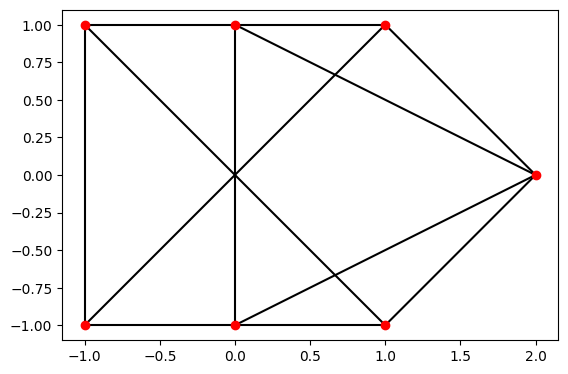

Noiseless error: 2.344938311615399e-10
Error with noise: 0.1153825442656476


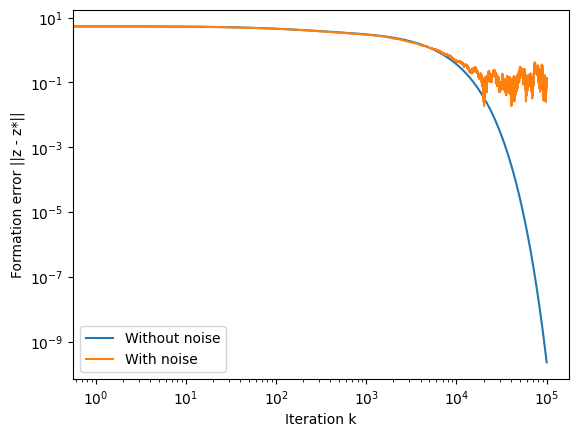

In [ ]:
k = 0
z = initial_positions.copy()
z_noisy = initial_positions.copy()
K = 200000

error_with_noise = np.zeros(K)
error = np.zeros(K)

# Simulation Loop
while k < K:
    # Calculate control law
    z_dot = (- np.kron(L, np.eye(2)) @ z.flatten()).reshape((num_agents, 2))
    z_dot_noisy = (- np.kron(L, np.eye(2)) @ z_noisy.flatten()).reshape((num_agents, 2))
        
    rng = np.random.default_rng()
    V = rng.multivariate_normal(mean=np.zeros(2), cov=noise_covariance, size=(num_agents, num_agents))
    z_dot_noisy += np.einsum('ii d->id', L @ (A[..., None] * V))
            
    # First three agents are leaders, which have fixed positions
    z[3:, :] += z_dot[3:, :] * timestep
    z_noisy[3:, :] += z_dot_noisy[3:, :] * timestep
    

    # Compute squared error to target positions
    error_with_noise[k] = np.linalg.norm(z_noisy - target_positions)
    error[k] = np.linalg.norm(z - target_positions)
    k += 1

plot_formation(z)
print('Noiseless error:', error[-1])
print('Error with noise:', error_with_noise[-1])
plt.plot(range(K), error, label='Without noise')
plt.plot(range(K), error_with_noise, label='With noise')
# plt.plot(range(K), error_with_noise, label='With noise')
plt.xlabel('Iteration k')
plt.ylabel('Formation error ||z - z*||')
plt.loglog()
plt.legend()

In [ ]:
np.round(np.kron(L, np.eye(2)) @ target_positions.flatten(), 3)

In [ ]:
print(np.round(L, 2))
W = np.diag([1, 2.2, 3.33, 4.444, 5.5555, 6.66666, 7.777777, 8.8888888, 9.99999999, 10.101010101010, 11.1111111111111, 12.121212121212121212])
W = np.diag([0.27, 0.27, 0.55, 0.27, 0.14, 0.27, 0.55, -0.14, -0.14, -0.14, 0.07, -0.14])
print(B.shape)
print(B @ W @ B.T)

Noiseless error: 7.319796127857394e-13
Error with noise: 0.059051541404766573


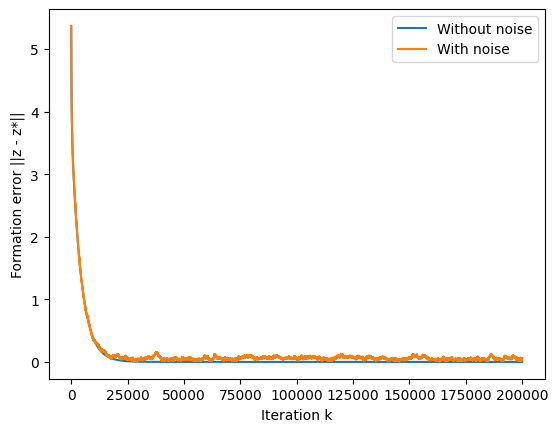

In [225]:
print('Noiseless error:', error[-1])
print('Error with noise:', error_with_noise[-1])
plt.plot(range(K), error, label='Without noise')
plt.plot(range(K), error_with_noise, label='With noise')
# plt.plot(range(K), error_with_noise, label='With noise')
plt.xlabel('Iteration k')
plt.ylabel('Formation error ||z - z*||')
plt.legend()

In [228]:
print(error[1500])
print(error_with_noise[1500])

2.6866378848857546
2.6957917345519853


[]

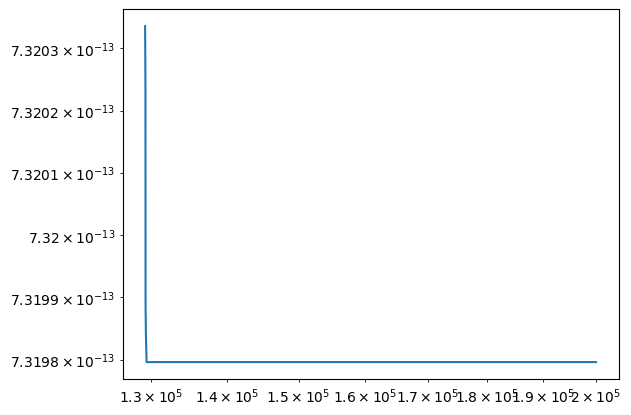

In [252]:
start = 129_300
plt.plot(range(start, K), error[start:], label='Without noise')
plt.loglog()
